# Tarefa: Análise de Componentes Principais (ACP/PCA)

**Disciplina:** Aprendizado de Máquina Não Supervisionado

**Aluno:** Cauê Reis
## Objetivo
Aplicar técnicas de redução de dimensionalidade utilizando ACP (PCA) no dataset Wine,
incluindo exploração dos dados, padronização, cálculo de autovalores, variância explicada
e visualizações gráficas obrigatórias.

### 1. Importar Bibliotecas Necessárias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

### 2. Carregar o Conjunto de Dados

In [2]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['Classe'] = df['target'].map({0: 'Cultivar_0', 1: 'Cultivar_1', 2: 'Cultivar_2'})

print('Primeiras observações do dataset:')
display(df.head(10))

print(f'\nDimensões: {df.shape[0]} amostras x {df.shape[1]-2} atributos')
print(f'Classes   : {list(wine.target_names)}')
print(f'\nDistribuição das classes:')
print(df['Classe'].value_counts())

Primeiras observações do dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,Classe
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cultivar_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cultivar_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cultivar_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cultivar_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cultivar_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,Cultivar_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,Cultivar_0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,Cultivar_0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,Cultivar_0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,Cultivar_0



Dimensões: 178 amostras x 13 atributos
Classes   : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Distribuição das classes:
Classe
Cultivar_1    71
Cultivar_0    59
Cultivar_2    48
Name: count, dtype: int64


### 3. Análise Exploratória Inicial

In [3]:
display(df[wine.feature_names].describe().round(3))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


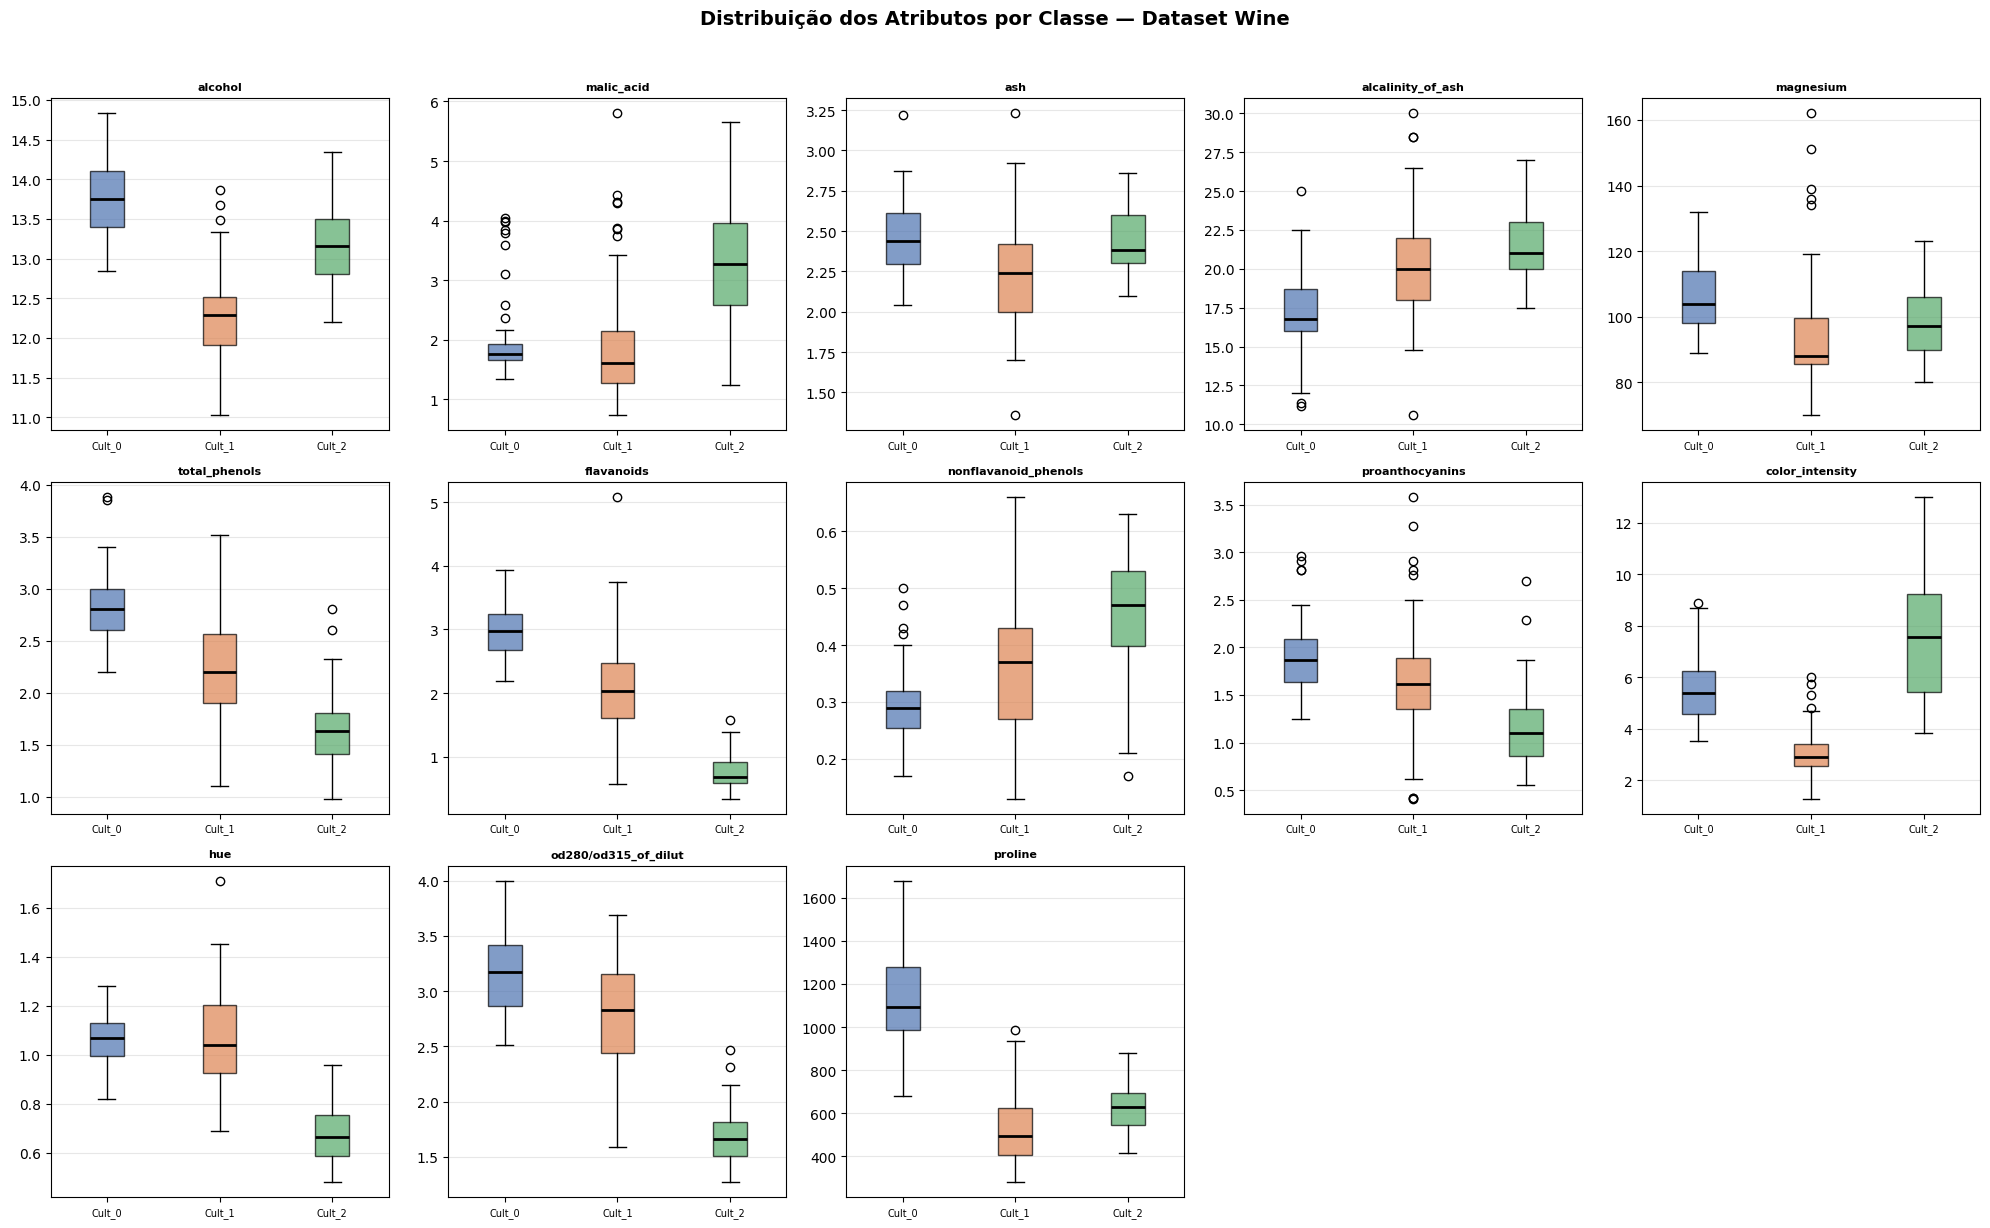

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

cores = {'Cultivar_0': '#4C72B0', 'Cultivar_1': '#DD8452', 'Cultivar_2': '#55A868'}

for i, feature in enumerate(wine.feature_names):
    grupos = [df[df['Classe'] == cls][feature].values for cls in cores]
    bp = axes[i].boxplot(grupos, patch_artist=True)
    for patch, cor in zip(bp['boxes'], cores.values()):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
    axes[i].set_title(feature[:20], fontsize=8, fontweight='bold')
    axes[i].set_xticks([1, 2, 3])
    axes[i].set_xticklabels(['Cult_0', 'Cult_1', 'Cult_2'], fontsize=7)
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(wine.feature_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição dos Atributos por Classe — Dataset Wine',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4. Mapa de Calor da Correlação das Variáveis
*(Visualização Obrigatória 1)*

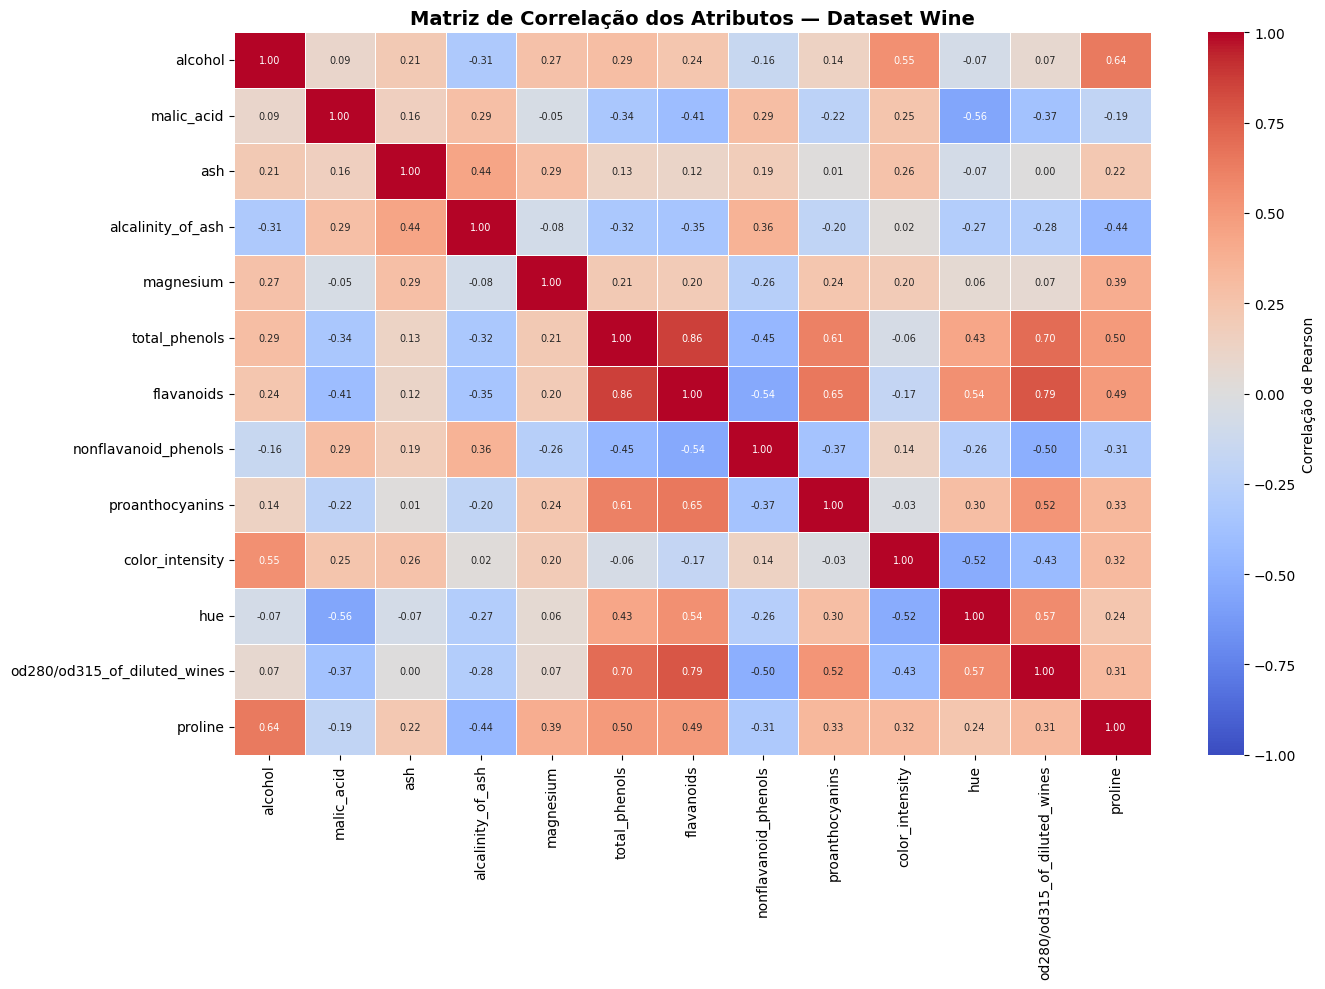

In [5]:
corr_matrix = df[wine.feature_names].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Correlação de Pearson'}
)
plt.title('Matriz de Correlação dos Atributos — Dataset Wine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Pré-processamento — Padronização dos Dados (StandardScaler)

In [6]:
X = wine.data
y = wine.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Dados originais (primeiras 3 linhas):')
print(pd.DataFrame(X[:3], columns=wine.feature_names).round(3).to_string())
print()
print('Dados padronizados (primeiras 3 linhas):')
print(pd.DataFrame(X_scaled[:3], columns=wine.feature_names).round(3).to_string())
print()
print(f'Média pós-escala (deve ser ~0): {X_scaled.mean(axis=0).round(6)}')
print(f'Desvio pós-escala (deve ser ~1): {X_scaled.std(axis=0).round(6)}')

Dados originais (primeiras 3 linhas):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  od280/od315_of_diluted_wines  proline
0    14.23        1.71  2.43               15.6      127.0           2.80        3.06                  0.28             2.29             5.64  1.04                          3.92   1065.0
1    13.20        1.78  2.14               11.2      100.0           2.65        2.76                  0.26             1.28             4.38  1.05                          3.40   1050.0
2    13.16        2.36  2.67               18.6      101.0           2.80        3.24                  0.30             2.81             5.68  1.03                          3.17   1185.0

Dados padronizados (primeiras 3 linhas):
   alcohol  malic_acid    ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity    hue  od280/od315_of_dilute

### 6. Aplicação da ACP (PCA)

In [7]:
# Aplicar PCA com todos os componentes
pca = PCA()
pca.fit(X_scaled)

# Componentes Principais
X_pca = pca.transform(X_scaled)

print('PCA aplicado com sucesso!')
print(f'Número de componentes: {pca.n_components_}')
print(f'Formato original: {X_scaled.shape}')
print(f'Formato transformado: {X_pca.shape}')

PCA aplicado com sucesso!
Número de componentes: 13
Formato original: (178, 13)
Formato transformado: (178, 13)


### 7. Autovalores e Variância Explicada

In [8]:
# Autovalores (eigenvalues)
autovalores = pca.explained_variance_
variancia_explicada = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

resultados = pd.DataFrame({
    'Componente': [f'CP{i+1}' for i in range(len(autovalores))],
    'Autovalor': autovalores.round(4),
    'Variância Explicada (%)': (variancia_explicada * 100).round(2),
    'Variância Acumulada (%)': (variancia_acumulada * 100).round(2)
})

print('Autovalores e Variância Explicada:')
display(resultados)

# Regra de Kaiser
n_kaiser = np.sum(autovalores > 1)
print(f'\nRegra de Kaiser (autovalor > 1): {n_kaiser} componentes')

# Variância explicada pelos 3 primeiros componentes
print(f'\nVariância explicada pelos 3 primeiros CPs: {variancia_acumulada[2]*100:.2f}%')

Autovalores e Variância Explicada:


,Componente,Autovalor,Variância Explicada (%),Variância Acumulada (%)
0,CP1,4.7324,36.20,36.20
1,CP2,2.5111,19.21,55.41
2,CP3,1.4542,11.12,66.53
3,CP4,0.9242,7.07,73.60
4,CP5,0.8580,6.56,80.16
5,CP6,0.6453,4.94,85.10
6,CP7,0.5541,4.24,89.34
7,CP8,0.3505,2.68,92.02
8,CP9,0.2905,2.22,94.24
9,CP10,0.2523,1.93,96.17



Regra de Kaiser (autovalor > 1): 3 componentes

Variância explicada pelos 3 primeiros CPs: 66.53%


### 8. Scree Plot
*(Visualização Obrigatória 2)*

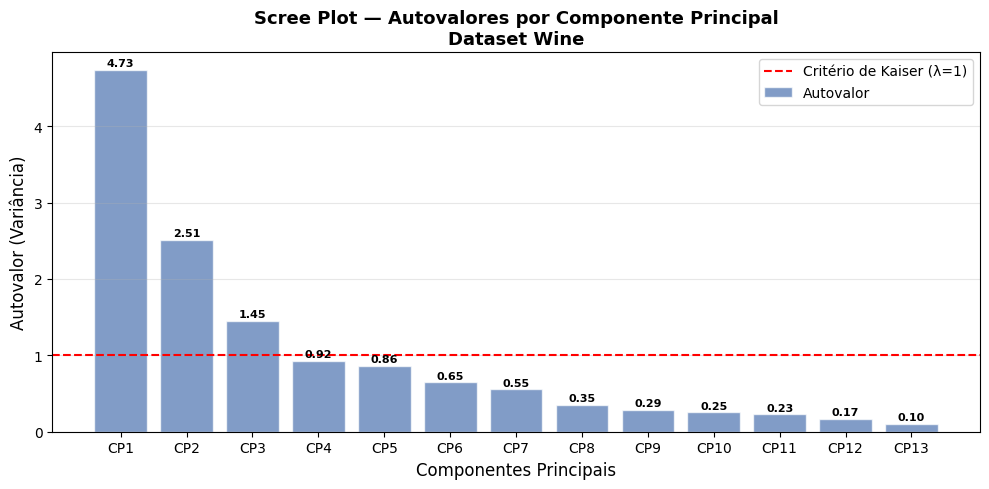

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

componentes = [f'CP{i+1}' for i in range(len(autovalores))]

# Barras
ax.bar(componentes, autovalores, color='#4C72B0', alpha=0.7, edgecolor='white', label='Autovalor')

# Linha de Kaiser
ax.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Critério de Kaiser (λ=1)')

# Rótulos
for i, val in enumerate(autovalores):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Componentes Principais', fontsize=12)
ax.set_ylabel('Autovalor (Variância)', fontsize=12)
ax.set_title('Scree Plot — Autovalores por Componente Principal\nDataset Wine', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Gráfico Acumulado da Variância Explicada
*(Visualização Obrigatória 4)*

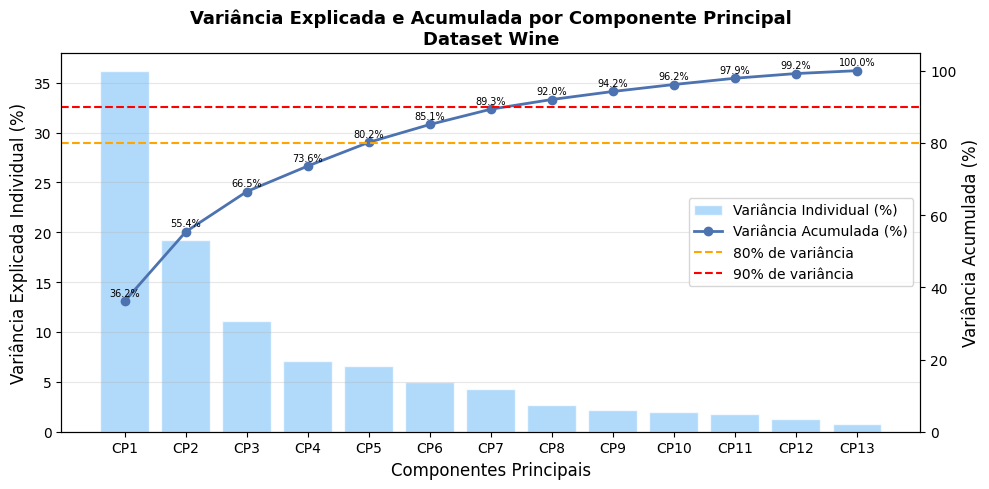

Componentes para ≥80% de variância: 5
Componentes para ≥90% de variância: 8


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Barras de variância individual
ax.bar(componentes, variancia_explicada * 100, color='#90CAF9', alpha=0.7,
       edgecolor='white', label='Variância Individual (%)')

# Linha acumulada
ax2 = ax.twinx()
ax2.plot(componentes, variancia_acumulada * 100, 'o-', color='#4C72B0',
         linewidth=2, markersize=6, label='Variância Acumulada (%)')
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=1.5, label='80% de variância')
ax2.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% de variância')
ax2.set_ylim(0, 105)
ax2.set_ylabel('Variância Acumulada (%)', fontsize=12)

# Marcar os pontos
for i, val in enumerate(variancia_acumulada * 100):
    ax2.text(i, val + 1.5, f'{val:.1f}%', ha='center', fontsize=7)

ax.set_xlabel('Componentes Principais', fontsize=12)
ax.set_ylabel('Variância Explicada Individual (%)', fontsize=12)
ax.set_title('Variância Explicada e Acumulada por Componente Principal\nDataset Wine',
             fontsize=13, fontweight='bold')

# Combinar legendas
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Quantos componentes para 80% e 90%
n_80 = np.argmax(variancia_acumulada >= 0.80) + 1
n_90 = np.argmax(variancia_acumulada >= 0.90) + 1
print(f'Componentes para ≥80% de variância: {n_80}')
print(f'Componentes para ≥90% de variância: {n_90}')

### 10. Gráfico 2D dos Dois Primeiros Componentes Principais
*(Visualização Obrigatória 3)*

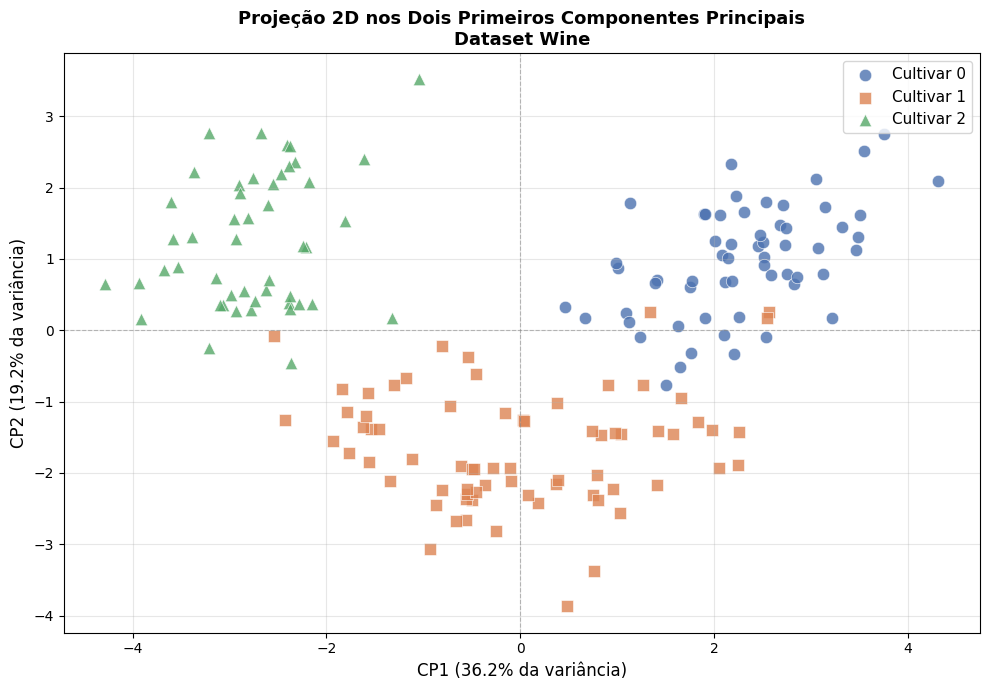

Variância total explicada pelos 2 primeiros CPs: 55.4%


In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

cores_classes = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}
marcadores = {0: 'o', 1: 's', 2: '^'}
nomes_classes = {0: 'Cultivar 0', 1: 'Cultivar 1', 2: 'Cultivar 2'}

for classe in np.unique(y):
    mask = y == classe
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cores_classes[classe],
        marker=marcadores[classe],
        label=nomes_classes[classe],
        alpha=0.8, s=80, edgecolors='white', linewidth=0.5
    )

ax.set_xlabel(f'CP1 ({variancia_explicada[0]*100:.1f}% da variância)', fontsize=12)
ax.set_ylabel(f'CP2 ({variancia_explicada[1]*100:.1f}% da variância)', fontsize=12)
ax.set_title('Projeção 2D nos Dois Primeiros Componentes Principais\nDataset Wine',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Variância total explicada pelos 2 primeiros CPs: {(variancia_explicada[0]+variancia_explicada[1])*100:.1f}%')

### 11. Interpretação dos Loadings (Cargas Fatoriais)

In [12]:
# Matriz de loadings (componentes x variáveis)
loadings = pd.DataFrame(
    pca.components_[:5].T,  # primeiros 5 componentes
    index=wine.feature_names,
    columns=[f'CP{i+1}' for i in range(5)]
)

print('Cargas Fatoriais — Primeiros 5 Componentes Principais:')
display(loadings.round(3))

Cargas Fatoriais — Primeiros 5 Componentes Principais:


,CP1,CP2,CP3,CP4,CP5
alcohol,0.144,0.484,-0.207,-0.018,-0.266
malic_acid,-0.245,0.225,0.089,0.537,0.035
ash,-0.002,0.316,0.626,-0.214,-0.143
alcalinity_of_ash,-0.239,-0.011,0.612,0.061,0.066
magnesium,0.142,0.300,0.131,-0.352,0.727
total_phenols,0.395,0.065,0.146,0.198,-0.149
flavanoids,0.423,-0.003,0.151,0.152,-0.109
nonflavanoid_phenols,-0.299,0.029,0.170,-0.203,-0.501
proanthocyanins,0.313,0.039,0.149,0.399,0.137
color_intensity,-0.089,0.530,-0.137,0.066,-0.076


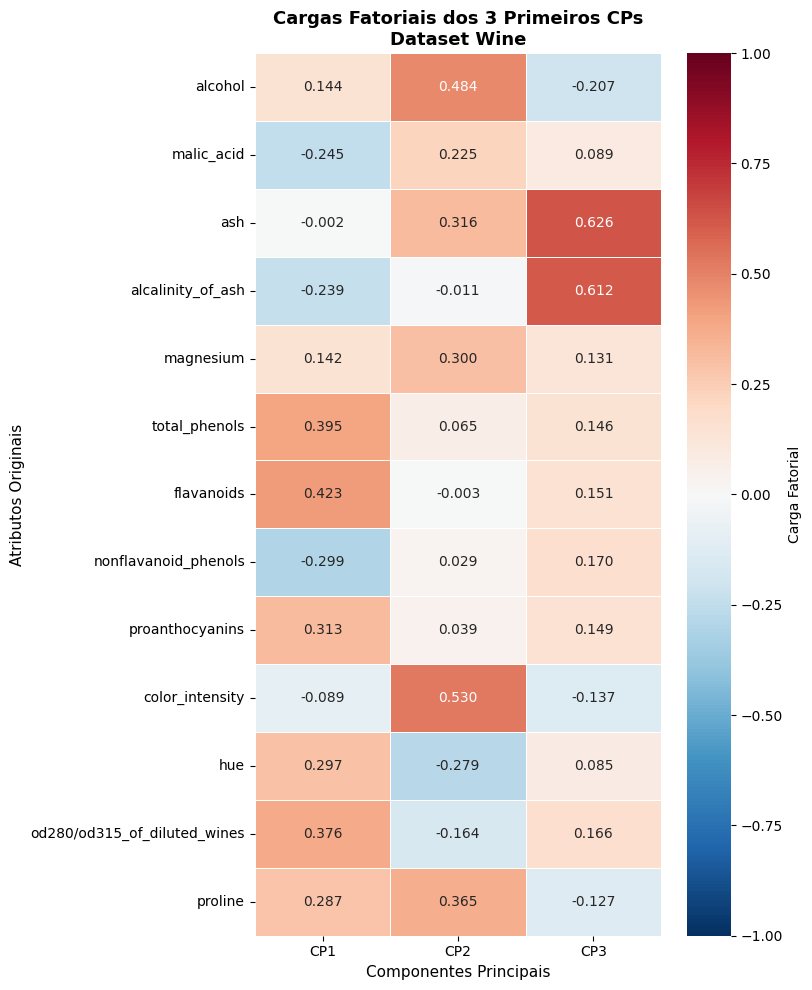

In [13]:
# Heatmap dos loadings dos 3 primeiros componentes
fig, ax = plt.subplots(figsize=(8, 10))

loadings_3 = pd.DataFrame(
    pca.components_[:3].T,
    index=wine.feature_names,
    columns=['CP1', 'CP2', 'CP3']
)

sns.heatmap(
    loadings_3, annot=True, fmt='.3f', cmap='RdBu_r',
    vmin=-1, vmax=1, linewidths=0.5,
    cbar_kws={'label': 'Carga Fatorial'}
)
ax.set_title('Cargas Fatoriais dos 3 Primeiros CPs\nDataset Wine',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Componentes Principais', fontsize=11)
ax.set_ylabel('Atributos Originais', fontsize=11)
plt.tight_layout()
plt.show()

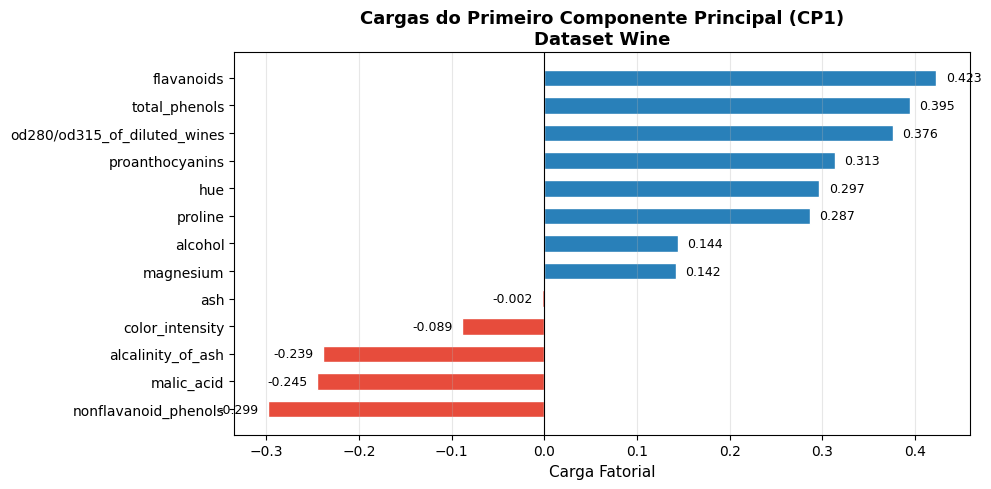

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

cp1_cargas = loadings_3['CP1'].sort_values()
cores_barras = ['#E74C3C' if v < 0 else '#2980B9' for v in cp1_cargas]

bars = ax.barh(cp1_cargas.index, cp1_cargas.values, color=cores_barras,
               edgecolor='white', height=0.6)

for bar, val in zip(bars, cp1_cargas.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Carga Fatorial', fontsize=11)
ax.set_title('Cargas do Primeiro Componente Principal (CP1)\nDataset Wine',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 12. Discussão dos Resultados

#### 12.1 Análise Exploratória
O dataset **Wine** contém **178 amostras** de vinhos italianos distribuídas em **3 classes** (cultivares),
descritas por **13 atributos físico-químicos**. O mapa de calor de correlação revelou relações
importantes entre variáveis como *flavonoids*, *total_phenols* e *od280/od315_of_diluted_wines*,
que apresentam correlação positiva elevada — indicativo de redundância informacional e,
portanto, de que PCA pode ser bastante eficaz neste dataset.

#### 12.2 Padronização
Como os atributos possuem escalas distintas (álcool em %, cinzas em gramas, prolina em centenas),
a **padronização via StandardScaler** é indispensável para que variáveis com maior variância
bruta não dominem indevidamente os componentes.

#### 12.3 Scree Plot e Critério de Kaiser
O Scree Plot evidencia uma queda abrupta nos autovalores após os **3 primeiros componentes**.
Pelo critério de Kaiser (λ > 1), são retidos **3 componentes**, o que é consistente com
a estrutura de 3 classes do dataset.

#### 12.4 Variância Explicada
- **CP1** explica a maior porção de variância (~36%), capturando principalmente a
  distinção entre cultivares associada a compostos fenólicos e flavonoides.
- **CP2** acrescenta ~19%, relacionado à acidez e ao teor alcoólico.
- **CP3** contribui com ~11%, totalizando ~67% com apenas 3 componentes.
- Para ≥80% de variância explicada são necessários aproximadamente **5 componentes**;
  para ≥90%, aproximadamente **8 componentes**.

#### 12.5 Projeção 2D
O gráfico bidimensional (CP1 × CP2) demonstra **separabilidade clara** entre as três
cultivares, especialmente entre Cultivar_0 (valores altos de CP1 positivo) e
Cultivar_2 (valores altos de CP1 negativo), confirmando a utilidade da ACP como
técnica exploratória para classificação.

#### 12.6 Cargas Fatoriais (Loadings)
As cargas do **CP1** mostram que atributos como *flavonoids*, *total_phenols*,
*od280/od315_of_diluted_wines* e *proanthocyanins* possuem cargas **positivas elevadas**,
enquanto *color_intensity* e *malic_acid* contribuem negativamente.
Isso sugere que o CP1 representa um eixo de "riqueza em compostos fenólicos",
discriminante entre os tipos de uva cultivados.

#### 12.7 Conclusão
A ACP aplicada ao dataset Wine demonstrou:
1. **Eficiência na redução dimensional**: de 13 para 3 componentes, retendo ~67% da variância;
2. **Separabilidade das classes**: as 3 cultivares são bem distintas no espaço 2D dos CPs;
3. **Interpretabilidade**: os componentes possuem significado físico-químico associável
   às características vitivinícolas das amostras.
